# Lecture Parquet + Entrainement Baseline

Notebook cible pour `date=2026-02-10` (plaque sans trou) et comparaison avec plaque avec trou.

In [60]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [61]:
# Chargement des 2 datasets: with hole (1) + without hole (0)
ROOT_WITH = Path('../data/raw/sim_v1')
ROOT_WITHOUT = Path('../data/raw/sim_v1_without_hole')

TARGET_COLS = ['max_displacement_m', 'max_von_mises_pa']
BASE_DROP_COLS = ['simulation_id', 'timestamp', 'solver_name', 'solver_version', 'data_version']

files_with = sorted(ROOT_WITH.rglob('*.parquet'))
files_without = sorted(ROOT_WITHOUT.rglob('*.parquet'))
if not files_with or not files_without:
    raise FileNotFoundError('Parquet manquants dans data/raw/sim_v1 ou data/raw/sim_v1_without_hole')

len(files_with), len(files_without)

(10, 1)

In [62]:
df_with = pd.concat((pd.read_parquet(f) for f in files_with), ignore_index=True)
df_with['with_hole'] = 1

df_without = pd.concat((pd.read_parquet(f) for f in files_without), ignore_index=True)
df_without['with_hole'] = 0

df = pd.concat([df_with, df_without], ignore_index=True)
print('shape:', df.shape)
df.head()

shape: (20050, 19)


,simulation_id,timestamp,max_displacement_m,max_von_mises_pa,solver_name,solver_version,data_version,material_category,dimension_category,length_m,height_m,young_modulus_pa,poisson_ratio,traction_pa,mesh_nx,mesh_ny,hole_radius_ratio,with_hole,geometry_type
0,441e59ef-2b2b-4c8b-82ad-23dc69523212,2026-02-10T13:14:06.315686+00:00,0.000003,5.598102e+05,dolfinx_fenics,dolfinx=0.10.0.post2;petsc=3.24.0;python=3.12.3,sim_v1,custom,custom,1.815725,0.308217,2.066687e+11,0.319737,3.883547e+05,120,24,NaN,1,NaN
1,14ce8eb2-0305-429a-8d59-643bd798963f,2026-02-10T13:14:07.121558+00:00,0.000011,1.543313e+06,dolfinx_fenics,dolfinx=0.10.0.post2;petsc=3.24.0;python=3.12.3,sim_v1,custom,custom,2.158558,0.475793,1.947006e+11,0.262811,1.100772e+06,120,24,NaN,1,NaN
2,a5e28d91-dc2e-49fb-8e0a-28604c284912,2026-02-10T13:14:07.688198+00:00,0.000006,1.962884e+06,dolfinx_fenics,dolfinx=0.10.0.post2;petsc=3.24.0;python=3.12.3,sim_v1,custom,custom,1.130357,0.561918,1.712377e+11,0.332276,1.086828e+06,120,24,NaN,1,NaN
3,042673bd-14fa-4f9a-bdaa-d18aee732f8a,2026-02-10T13:14:08.259102+00:00,0.000015,2.582167e+06,dolfinx_fenics,dolfinx=0.10.0.post2;petsc=3.24.0;python=3.12.3,sim_v1,custom,custom,0.886306,0.368384,7.552985e+10,0.332763,1.463329e+06,120,24,NaN,1,NaN
4,15a8b5eb-5cf9-454b-8d7c-37461a2ab5dc,2026-02-10T13:14:09.011746+00:00,0.000012,2.498832e+06,dolfinx_fenics,dolfinx=0.10.0.post2;petsc=3.24.0;python=3.12.3,sim_v1,custom,custom,1.788749,0.264354,2.251652e+11,0.339312,1.756767e+06,120,24,NaN,1,NaN


In [63]:
print('Colonnes:')
for c in df.columns:
    print('-', c)

Colonnes:
- simulation_id
- timestamp
- max_displacement_m
- max_von_mises_pa
- solver_name
- solver_version
- data_version
- material_category
- dimension_category
- length_m
- height_m
- young_modulus_pa
- poisson_ratio
- traction_pa
- mesh_nx
- mesh_ny
- hole_radius_ratio
- with_hole
- geometry_type


In [64]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
max_displacement_m,20050.0,1.213975e-05,1.002870e-05,5.419259e-07,5.236975e-06,9.519029e-06,1.609630e-05,2.461524e-04
max_von_mises_pa,20050.0,2.515606e+06,1.485917e+06,2.079426e+05,1.333312e+06,2.286926e+06,3.389009e+06,7.818950e+06
length_m,20050.0,1.349832e+00,4.904809e-01,5.000803e-01,9.257801e-01,1.354881e+00,1.772520e+00,2.199895e+00
height_m,20050.0,3.412564e-01,1.497811e-01,8.002981e-02,2.107494e-01,3.423401e-01,4.715329e-01,5.999881e-01
young_modulus_pa,20050.0,1.475808e+11,4.747922e+10,6.500217e+10,1.063670e+11,1.479067e+11,1.885276e+11,2.299913e+11
poisson_ratio,20050.0,3.000393e-01,2.891236e-02,2.500019e-01,2.746267e-01,3.003660e-01,3.251505e-01,3.499994e-01
traction_pa,20050.0,1.201319e+06,5.773010e+05,2.000549e+05,7.022584e+05,1.203124e+06,1.697782e+06,2.199965e+06
mesh_nx,20050.0,1.200000e+02,0.000000e+00,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02
mesh_ny,20050.0,2.400000e+01,0.000000e+00,2.400000e+01,2.400000e+01,2.400000e+01,2.400000e+01,2.400000e+01
hole_radius_ratio,10000.0,1.251076e-01,4.364981e-02,5.000198e-02,8.730524e-02,1.250992e-01,1.631939e-01,1.999625e-01


In [65]:
summary = {
    'rows': int(len(df)),
    'n_files_with': int(len(files_with)),
    'n_files_without': int(len(files_without)),
    'n_files_total': int(len(files_with) + len(files_without)),
}
summary

{'rows': 20050, 'n_files_with': 10, 'n_files_without': 1, 'n_files_total': 11}

In [66]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

geometry_type        20000
hole_radius_ratio    10050
dtype: int64

## Preprocessing + Split

In [67]:
# Nettoyage de base
if 'simulation_id' in df.columns:
    df = df.drop_duplicates(subset=['simulation_id', 'with_hole']).copy()
else:
    df = df.drop_duplicates().copy()

# Colonnes entierement vides
all_na_cols = [c for c in df.columns if df[c].isna().all()]
if all_na_cols:
    df = df.drop(columns=all_na_cols)

for col in ['hole_radius_ratio', 'hole_cx_ratio', 'hole_cy_ratio']:
    if col not in df.columns:
        df[col] = 0.0
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

if 'geometry_type' not in df.columns:
    df['geometry_type'] = pd.NA

if 'with_hole' in df.columns:
    df['with_hole'] = pd.to_numeric(df['with_hole'], errors='coerce').fillna(0).astype(int)

df['geometry_type'] = df['geometry_type'].astype('string').str.strip()
missing_gt = df['geometry_type'].isna() | (df['geometry_type'] == '')
if 'with_hole' in df.columns:
    df.loc[missing_gt & df['with_hole'].eq(1), 'geometry_type'] = 'with_hole'
    df.loc[missing_gt & df['with_hole'].eq(0), 'geometry_type'] = 'without_hole'
else:
    df.loc[missing_gt, 'geometry_type'] = 'without_hole'

df['area_m2'] = df['length_m'] * df['height_m']
df['aspect_ratio'] = df['length_m'] / df['height_m']
df['epsilon_scal'] = df['traction_pa'] / df['young_modulus_pa']
df['mesh_total_cells'] = df['mesh_nx'] * df['mesh_ny']
df['mesh_density'] = df['mesh_total_cells'] / df['area_m2']

drop_cols = [c for c in BASE_DROP_COLS if c in df.columns]
mesh_excluded = ['mesh_nx', 'mesh_ny', 'mesh_total_cells', 'mesh_density']
feature_cols = [
    c for c in df.columns
    if c not in TARGET_COLS + drop_cols + mesh_excluded
]

model_df = df[feature_cols + TARGET_COLS].dropna().copy()
X = model_df[feature_cols]
y = model_df[TARGET_COLS]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

print('features:', len(feature_cols))
print('train/val/test:', len(X_train), len(X_val), len(X_test))

features: 15
train/val/test: 14035 3007 3008


,max_displacement_m,max_von_mises_pa,length_m,height_m,young_modulus_pa,poisson_ratio,traction_pa,hole_radius_ratio,with_hole,area_m2,aspect_ratio,epsilon_scal
max_displacement_m,1.000000,0.420599,0.453140,-0.018345,-0.429756,-0.006740,0.575416,-0.000881,-0.227271,0.262014,0.239764,0.764733
max_von_mises_pa,0.420599,1.000000,-0.072093,0.103391,0.001082,0.037982,0.810946,0.499778,0.037679,0.032626,-0.110350,0.615674
length_m,0.453140,-0.072093,1.000000,-0.000315,-0.005019,-0.001722,0.000952,0.005702,-0.003360,0.615371,0.480343,0.001556
height_m,-0.018345,0.103391,-0.000315,1.000000,0.001184,0.004853,0.011561,-0.001368,-0.005128,0.740298,-0.723923,0.009121
young_modulus_pa,-0.429756,0.001082,-0.005019,0.001184,1.000000,-0.002686,0.006071,-0.002024,0.000660,-0.001204,-0.005376,-0.557749
poisson_ratio,-0.006740,0.037982,-0.001722,0.004853,-0.002686,1.000000,0.002793,0.003687,0.004461,0.004359,-0.006728,0.000433
traction_pa,0.575416,0.810946,0.000952,0.011561,0.006071,0.002793,1.000000,-0.003400,0.007416,0.011296,-0.003385,0.754946
hole_radius_ratio,-0.000881,0.499778,0.005702,-0.001368,-0.002024,0.003687,-0.003400,1.000000,0.044738,0.005149,0.000241,0.000777
with_hole,-0.227271,0.037679,-0.003360,-0.005128,0.000660,0.004461,0.007416,0.044738,1.000000,-0.006124,0.005838,0.006248
area_m2,0.262014,0.032626,0.615371,0.740298,-0.001204,0.004359,0.011296,0.005149,-0.006124,1.000000,-0.310470,0.008643


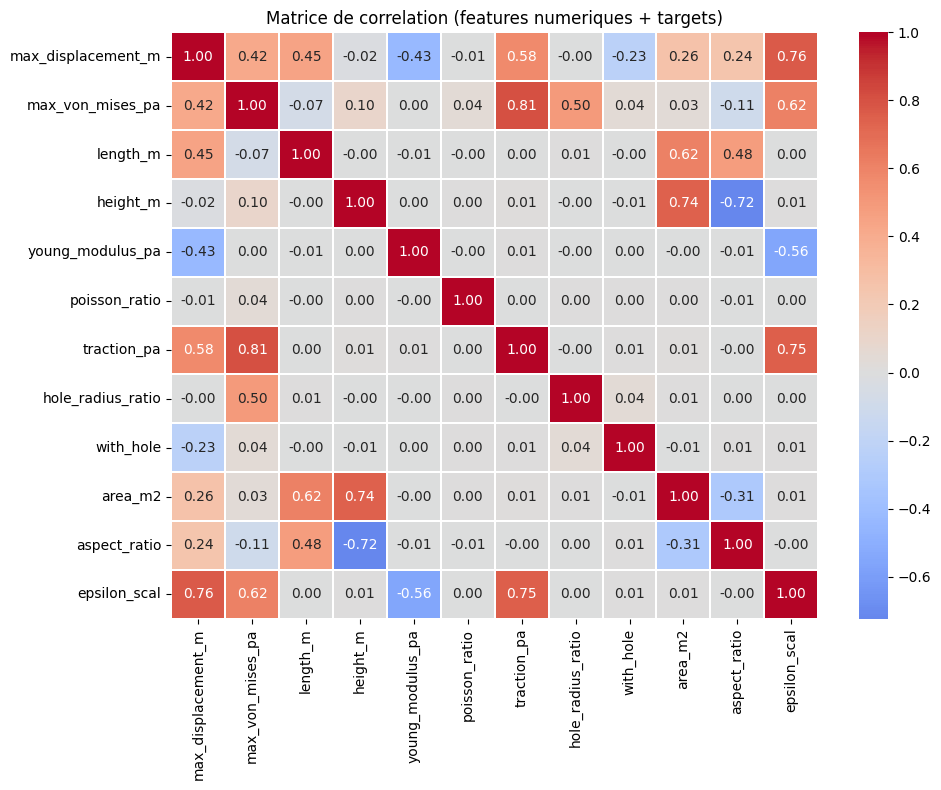

In [68]:
# Matrice de correlation sur colonnes utiles (sans constantes)
corr_cols = TARGET_COLS + [c for c in feature_cols if pd.api.types.is_numeric_dtype(model_df[c])]
corr_df = model_df[corr_cols].copy()
nunique = corr_df.nunique(dropna=False)
corr_df = corr_df.loc[:, nunique > 1]
corr_matrix = corr_df.corr(numeric_only=True)
display(corr_matrix)
try:
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0.0, annot=True, fmt='.2f', linewidths=0.3)
    plt.title('Matrice de correlation (features numeriques + targets)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Heatmap non affichee ({e}). Le tableau de correlation est affiche ci-dessus.')


## Train Baseline

In [69]:
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

normalize_num_features = True
use_log_targets = True

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler() if normalize_num_features else 'passthrough', num_cols),
])

base_model = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', base_model),
])

def _to_log_targets(y_df: pd.DataFrame) -> pd.DataFrame:
    # securite numerique: log1p exige y >= -1
    return np.log1p(y_df.clip(lower=0.0)) if use_log_targets else y_df

y_train_fit = _to_log_targets(y_train)
pipe.fit(X_train, y_train_fit)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [70]:
def _invert_target_scale(arr: np.ndarray) -> np.ndarray:
    out = np.expm1(arr) if use_log_targets else arr
    return np.maximum(out, 0.0)

def evaluate_split(name: str, y_true: pd.DataFrame, y_pred: np.ndarray) -> pd.DataFrame:
    rows = []
    for i, target in enumerate(TARGET_COLS):
        yt = y_true[target].to_numpy(dtype=float)
        yp = y_pred[:, i].astype(float)
        rows.append({
            'split': name,
            'target': target,
            'mae': float(mean_absolute_error(yt, yp)),
            'rmse': float(np.sqrt(mean_squared_error(yt, yp))),
            'r2': float(r2_score(yt, yp)),
        })
    return pd.DataFrame(rows)

val_pred = _invert_target_scale(pipe.predict(X_val).astype(float))
test_pred = _invert_target_scale(pipe.predict(X_test).astype(float))
metrics = pd.concat([
    evaluate_split('val', y_val, val_pred),
    evaluate_split('test', y_test, test_pred),
], ignore_index=True)
metrics

,split,target,mae,rmse,r2
0,val,max_displacement_m,7.892144e-07,0.000003,0.938222
1,val,max_von_mises_pa,5.034644e+04,76220.111362,0.997359
2,test,max_displacement_m,7.509183e-07,0.000003,0.909046
3,test,max_von_mises_pa,5.049688e+04,82113.474891,0.996888


In [71]:
# Validation K-Fold (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(X), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    fold_pipe = clone(pipe)
    y_tr_fit = _to_log_targets(y_tr)
    fold_pipe.fit(X_tr, y_tr_fit)
    y_va_pred = _invert_target_scale(fold_pipe.predict(X_va).astype(float))

    fold_metrics = evaluate_split(f'kfold_{fold}', y_va, y_va_pred)
    rows.append(fold_metrics)

kfold_metrics = pd.concat(rows, ignore_index=True)
display(kfold_metrics.head())
kfold_metrics.groupby('target')[['mae', 'rmse', 'r2']].mean()

,split,target,mae,rmse,r2
0,kfold_1,max_displacement_m,7.895818e-07,0.000003,0.905345
1,kfold_1,max_von_mises_pa,5.007830e+04,79583.935817,0.997122
2,kfold_2,max_displacement_m,6.515414e-07,0.000001,0.982401
3,kfold_2,max_von_mises_pa,4.805193e+04,75482.149445,0.997397
4,kfold_3,max_displacement_m,6.722389e-07,0.000002,0.948078


,mae,rmse,r2
target,,,
max_displacement_m,7.041103e-07,0.000002,0.949357
max_von_mises_pa,4.945867e+04,77772.748094,0.997259


In [72]:
# Synthese K-Fold: moyenne, ecart-type et statut de stabilite
kfold_summary = (
    kfold_metrics.groupby('target')[['mae', 'rmse', 'r2']]
    .agg(['mean', 'std'])
    .round(6)
)

flat = kfold_summary.copy()
flat.columns = [f'{m}_{s}' for m, s in flat.columns]

def stability_flag(r2_std: float, r2_mean: float) -> str:
    if pd.isna(r2_std) or pd.isna(r2_mean):
        return 'indetermine'
    if r2_std <= 0.01 and r2_mean >= 0.95:
        return 'stable'
    if r2_std <= 0.03 and r2_mean >= 0.90:
        return 'acceptable'
    return 'a_surv'

flat['stability'] = [stability_flag(v_std, v_mean) for v_std, v_mean in zip(flat['r2_std'], flat['r2_mean'])]
display(flat)

,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,stability
target,,,,,,,
max_displacement_m,0.000001,0.00000,0.000002,0.000001,0.949357,0.029950,acceptable
max_von_mises_pa,49458.667439,856.57543,77772.748094,2101.148361,0.997259,0.000133,stable


In [73]:
# Sauvegarde des metriques
metrics.to_csv('../data/processed/baseline_metrics.csv', index=False)
print('Metriques enregistrees: ../data/processed/baseline_metrics.csv')

Metriques enregistrees: ../data/processed/baseline_metrics.csv


In [74]:
# Sauvegarde du modele
model_path = Path('../data/processed/baseline_model.joblib')
joblib.dump(pipe, model_path)
print(f'Modele enregistre: {model_path}')

Modele enregistre: ..\data\processed\baseline_model.joblib


In [75]:
# Inference sur un nouveau cas (hors dataset) + controle de confiance
new_case = {
    'material_category': 'custom',
    'dimension_category': 'custom',
    'length_m': float(X_train['length_m'].median()) if 'length_m' in X_train.columns else 0.1,
    'height_m': float(X_train['height_m'].median()) if 'height_m' in X_train.columns else 0.05,
    'young_modulus_pa': float(X_train['young_modulus_pa'].median()) if 'young_modulus_pa' in X_train.columns else 2.1e11,
    'poisson_ratio': float(X_train['poisson_ratio'].median()) if 'poisson_ratio' in X_train.columns else 0.3,
    'traction_pa': float(X_train['traction_pa'].median()) if 'traction_pa' in X_train.columns else 1e6,
    'with_hole': 0.0,
    'geometry_type': 'without_hole',
    'hole_radius_ratio': 0.0,
    'hole_cx_ratio': 0.0,
    'hole_cy_ratio': 0.0,
}

new_case['area_m2'] = new_case['length_m'] * new_case['height_m']
new_case['aspect_ratio'] = new_case['length_m'] / new_case['height_m']
new_case['epsilon_scal'] = new_case['traction_pa'] / new_case['young_modulus_pa']

new_X = pd.DataFrame([{c: new_case.get(c, 0.0) for c in feature_cols}])
new_pred = _invert_target_scale(pipe.predict(new_X).astype(float))[0]
dict(zip(TARGET_COLS, new_pred.tolist()))

{'max_displacement_m': 4.9476301183776776e-05,
 'max_von_mises_pa': 1713393.3308795844}

In [76]:
# Comparaison modele vs verite terrain sur 1 echantillon du test set
sample_idx = X_test.index[0]
sample_X = X_test.loc[[sample_idx]]
sample_true = y_test.loc[[sample_idx]].copy()
sample_pred = _invert_target_scale(pipe.predict(sample_X).astype(float))
sample_pred_df = pd.DataFrame(sample_pred, index=sample_true.index, columns=TARGET_COLS)
display(sample_true)
sample_pred_df

,max_displacement_m,max_von_mises_pa
17443,0.000008,3.472092e+06


,max_displacement_m,max_von_mises_pa
17443,0.000008,3.372783e+06


In [77]:
# Construire pred_df sur tout le test set
y_true_all = y_test.to_numpy(dtype=float)
y_pred_all = _invert_target_scale(pipe.predict(X_test).astype(float))

rows = []
for i, target in enumerate(TARGET_COLS):
    err = y_pred_all[:, i] - y_true_all[:, i]
    rows.append(pd.DataFrame({
        'target': target,
        'y_true': y_true_all[:, i],
        'y_pred': y_pred_all[:, i],
        'abs_error': np.abs(err),
        'ape': np.abs(err) / np.maximum(np.abs(y_true_all[:, i]), 1e-12),
    }))
pred_df = pd.concat(rows, ignore_index=True)
pred_df.head()

,target,y_true,y_pred,abs_error,ape
0,max_displacement_m,0.000008,0.000008,1.053241e-07,0.013517
1,max_displacement_m,0.000008,0.000005,2.567688e-06,0.322214
2,max_displacement_m,0.000004,0.000004,3.349251e-08,0.008961
3,max_displacement_m,0.000023,0.000023,1.503853e-07,0.006411
4,max_displacement_m,0.000003,0.000003,4.157687e-08,0.014317


In [78]:
pred_df.groupby('target').agg(
    n=('abs_error', 'size'),
    mae=('abs_error', 'mean'),
    median_abs_error=('abs_error', 'median'),
    mape=('ape', 'mean'),
)

,n,mae,median_abs_error,mape
target,,,,
max_displacement_m,3008,7.509183e-07,3.049272e-07,0.052393
max_von_mises_pa,3008,5.049688e+04,2.932606e+04,0.021875
